# **Complete EDA On Google Playstore Apps**

## About Dataset

This is google playstore apps dataset available at [Kaggle](https://www.kaggle.com/lava18/google-play-store-apps)


`Context`

While many public datasets (on Kaggle and the like) provide Apple App Store data, there are not many counterpart datasets available for Google Play Store apps anywhere on the web. On digging deeper, I found out that iTunes App Store page deploys a nicely indexed appendix-like structure to allow for simple and easy web scraping. On the other hand, Google Play Store uses sophisticated modern-day techniques (like dynamic page load) using JQuery making scraping more challenging.

`Content`
Each app (row) has values for catergory, rating, size, and more.

`Acknowledgements`

This information is scraped from the Google Play Store. This app information would not be available without it.

`Inspiration`

The Play Store apps data has enormous potential to drive app-making businesses to success. Actionable insights can be drawn for developers to work on and capture the Android market!

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

**ignore warnings**

In [2]:
import warnings
warnings.filterwarnings("ignore")

## 2.0 Data Loading, Filtering And Cleaning

. Load the csv file with the pandas

. creating the dataframe and understanding the data present in the dataset using pandas

. Dealing with the missing data, outliers and the incorrect records

In [3]:
df = pd.read_csv(r"D:\OneDrive\Desktop\data-analysis-course-preply\lectures\lecture-03-Google-Playstore-EDA\googleplaystore.csv")

In [4]:
df.head()

,a,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Unnamed: 13
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,NaN
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,NaN
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,NaN
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,NaN


checking columns in the dataset

In [5]:
df.columns

Index(['a', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Unnamed: 13'],
      dtype='str')

### checking number of rows and columns

In [6]:
df.shape

(10841, 14)

### checking what kind of data types we have in the dataset

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   a               10841 non-null  str    
 1   Category        10840 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  int64  
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10841 non-null  str    
 9   Genres          10840 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10839 non-null  str    
 13  Unnamed: 13     0 non-null      float64
dtypes: float64(2), int64(1), str(11)
memory usage: 1.2 MB


In [8]:
df.describe()

,Rating,Reviews,Unnamed: 13
count,9367.000000,1.084100e+04,0.0
mean,4.191513,4.441119e+05,NaN
std,0.515735,2.927629e+06,NaN
min,1.000000,0.000000e+00,NaN
25%,4.000000,3.800000e+01,NaN
50%,4.300000,2.094000e+03,NaN
75%,4.500000,5.476800e+04,NaN
max,5.000000,7.815831e+07,NaN


## Observation 1

-> We have 10841 and 13 columns in the dataset

-> We have columns of different data types

-> The columns in the dataset are: 

`'a', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Unnamed: 13'`

-> There are some missing values in the dataset, we'll handle them latter

-> There are some columns present which should be numeric but are not numeric

`Size` , `Price` , `Installs`

### **Converting Size Column To Numeric**

In [9]:
# check if size column has null values or not
df['Size'].isnull().sum()

np.int64(0)

we don't have null values, we are good to go

In [10]:
pd.set_option('display.max_columns', None) # this is to display all the columns in the dataframe
pd.set_option('display.max_rows', None) # this is to display all the rows in the dataframe

In [11]:
# checking unique values inside Size columns
df['Size'].unique()

<StringArray>
[  '19M',   '14M',  '8.7M',   '25M',  '2.8M',  '5.6M',   '29M',   '33M',
  '3.1M',   '28M',
 ...
  '467k',  '157k',   '44k',  '676k',   '67k',  '552k',  '885k', '1020k',
  '582k',  '619k']
Length: 461, dtype: str

In [12]:
# find the values inside Size column that has 'M' in it
df['Size'].loc[df['Size'].str.contains('M')].value_counts().sum()
  

np.int64(8830)

In [13]:
# find the values inside Size column that has 'K' in it
df['Size'].loc[df['Size'].str.contains('k')].value_counts().sum()

np.int64(316)

In [14]:
# find the values inside Size column that has Varies with device in it
df['Size'].loc[df['Size'].str.contains('Varies with device')].value_counts().sum()

np.int64(1695)

In [15]:
# Total values inside size column
df['Size'].value_counts().sum()

np.int64(10841)

## Observation 2

`We have 8830 values in M units`

`We have 316 values in k units`

`We have 1695 value in Varies with device`

In [16]:
# step 1: WE will  covert 'M'=  10^6 and K = 10^3 into bytes and varies with device as well 
# And then convert them into numeric

def convert_size(size):
    
    if isinstance(size, str): #isinstance(object, type)  -> True, if the object is of that type
        
        if 'k' in size:   # chcek if size is a string like size = '19M' And then isinstance(size, str) returns True
            return float(size.replace('k', '')) * 1024
        # size.replace -> 
        elif 'M' in size:
            return float(size.replace('M', '')) * 1024 * 1024
        elif 'Varies with device' in size:
            return np.nan  #NUMPY
    return size

df['Size'] = df['Size'].apply(convert_size)
    

In [17]:
# rename the column name 'Size' to 'Size_in_bytes'
#1838683673

df.rename(columns={'Size': 'Size_in_bytes'}, inplace=True)

In [18]:
# making a new column called 'Size in Mb' which will have the size in MB
# 73863M
df['Size_in_Mb'] = df['Size_in_bytes'].apply(lambda x: x/(1024*1024))

`Acheivement`

We converted the Size column from categorical to numeric


## Dealing With `Installs` Column

In [19]:
# let's check the null values
df['Installs'].isnull().sum()

np.int64(0)

we don't have any missing values, so we are good to go

In [20]:
# let's have a look at unique values
df['Installs'].unique()

<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0']
Length: 21, dtype: str

`Problems In Installs Columns`

There are 3 main problems:

1: Column data type is string

2: Values are with +

3: There is a comma between numbers

In [21]:
# let's have a look at the plus sign inside column
df['Installs'].loc[df['Installs'].str.contains('\+')].value_counts().sum()

np.int64(10840)

In [22]:
df['Installs'].value_counts().sum()

np.int64(10841)

-> The only problem in this column is the + icon, we need to remove it and then covert the column to numeric

-> We don't have missing values, the only problem is one 0 having no plus sign

-> We'll remove the + icon and comma

In [23]:
# Let's remove the plus sign and convert it into numeric
df['Installs'] = df['Installs'].apply(lambda x: str(x).replace('+', '').replace(',', ''))
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')



In [24]:
df['Installs'].dtype

dtype('int64')

In [25]:
df.describe()

,Rating,Reviews,Size_in_bytes,Installs,Unnamed: 13,Size_in_Mb
count,9367.000000,1.084100e+04,9.146000e+03,1.084100e+04,0.0,9146.000000
mean,4.191513,4.441119e+05,2.255921e+07,1.546291e+07,NaN,21.514141
std,0.515735,2.927629e+06,2.368595e+07,8.502557e+07,NaN,22.588679
min,1.000000,0.000000e+00,8.704000e+03,0.000000e+00,NaN,0.008301
25%,4.000000,3.800000e+01,5.138022e+06,1.000000e+03,NaN,4.900000
50%,4.300000,2.094000e+03,1.363149e+07,1.000000e+05,NaN,13.000000
75%,4.500000,5.476800e+04,3.145728e+07,5.000000e+06,NaN,30.000000
max,5.000000,7.815831e+07,1.048576e+08,1.000000e+09,NaN,100.000000


`Acheivement`

We have successfully converted the categorical vallues of Installs column to Numeric

## Dealing with the `Price`  column

In [26]:
# let's check null values
df['Price'].isnull().sum()

np.int64(0)

In [27]:
# let's have a look at unique values
df['Price'].unique()

<StringArray>
[      '0',   '$4.99',   '$3.99',   '$6.99',   '$1.49',   '$2.99',   '$7.99',
   '$5.99',   '$3.49',   '$1.99',   '$9.99',   '$7.49',   '$0.99',   '$9.00',
   '$5.49',  '$10.00',  '$24.99',  '$11.99',  '$79.99',  '$16.99',  '$14.99',
   '$1.00',  '$29.99',  '$12.99',   '$2.49',  '$10.99',   '$1.50',  '$19.99',
  '$15.99',  '$33.99',  '$74.99',  '$39.99',   '$3.95',   '$4.49',   '$1.70',
   '$8.99',   '$2.00',   '$3.88',  '$25.99', '$399.99',  '$17.99', '$400.00',
   '$3.02',   '$1.76',   '$4.84',   '$4.77',   '$1.61',   '$2.50',   '$1.59',
   '$6.49',   '$1.29',   '$5.00',  '$13.99', '$299.99', '$379.99',  '$37.99',
  '$18.99', '$389.99',  '$19.90',   '$8.49',   '$1.75',  '$14.00',   '$4.85',
  '$46.99', '$109.99', '$154.99',   '$3.08',   '$2.59',   '$4.80',   '$1.96',
  '$19.40',   '$3.90',   '$4.59',  '$15.46',   '$3.04',   '$4.29',   '$2.60',
   '$3.28',   '$4.60',  '$28.99',   '$2.95',   '$2.90',   '$1.97', '$200.00',
  '$89.99',   '$2.56',  '$30.99',   '$3.61', '$394

In [28]:
df['Price'].value_counts()

Price
0          10041
$0.99        148
$2.99        129
$1.99         73
$4.99         72
$3.99         63
$1.49         46
$5.99         30
$2.49         26
$9.99         21
$6.99         13
$399.99       12
$14.99        11
$4.49          9
$7.99          7
$3.49          7
$24.99         7
$29.99         7
$5.49          6
$19.99         6
$11.99         5
$12.99         5
$8.99          5
$6.49          5
$10.00         3
$16.99         3
$1.00          3
$2.00          3
$7.49          2
$9.00          2
$79.99         2
$10.99         2
$33.99         2
$39.99         2
$3.95          2
$1.70          2
$17.99         2
$13.99         2
$8.49          2
$1.50          1
$15.99         1
$74.99         1
$3.88          1
$25.99         1
$400.00        1
$3.02          1
$1.76          1
$4.84          1
$4.77          1
$1.61          1
$2.50          1
$1.59          1
$1.29          1
$5.00          1
$299.99        1
$379.99        1
$37.99         1
$18.99         1
$389.99 

In [29]:
# check values having $ sign with it
df['Price'].loc[df['Price'].str.contains('\$')].value_counts().sum()

np.int64(800)

In [30]:
# we'll count the values inside the column Price having '0' but not $ sign 
df['Price'].loc[df['Price'].str.contains('0')].value_counts().sum()

np.int64(10224)


**We have only 2 kind of values inside the column first is 0 and second is $**

**We just need to remove dollar sign and covert the column to numeric**

In [31]:
df['Price'] = df['Price'].apply(lambda x: str(x).replace('$', ''))
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [32]:
df['Price'].dtype

dtype('float64')

In [33]:
df.describe()

,Rating,Reviews,Size_in_bytes,Installs,Price,Unnamed: 13,Size_in_Mb
count,9367.000000,1.084100e+04,9.146000e+03,1.084100e+04,10841.000000,0.0,9146.000000
mean,4.191513,4.441119e+05,2.255921e+07,1.546291e+07,1.027273,NaN,21.514141
std,0.515735,2.927629e+06,2.368595e+07,8.502557e+07,15.948971,NaN,22.588679
min,1.000000,0.000000e+00,8.704000e+03,0.000000e+00,0.000000,NaN,0.008301
25%,4.000000,3.800000e+01,5.138022e+06,1.000000e+03,0.000000,NaN,4.900000
50%,4.300000,2.094000e+03,1.363149e+07,1.000000e+05,0.000000,NaN,13.000000
75%,4.500000,5.476800e+04,3.145728e+07,5.000000e+06,0.000000,NaN,30.000000
max,5.000000,7.815831e+07,1.048576e+08,1.000000e+09,400.000000,NaN,100.000000


## Observations:
---
- Now, we have only 6 columns as numeric data type.
- We can observe their descriptive statistics. and make tons of observations as per our hypotheses.
- We can see that the `Rating` column has a minimum value of `1` and a maximum value of `5`, which is the range of rating, and the mean is `4.19` which is a good rating. On an average people give this rating.
- We can see that the `Reviews` column has a minimum value of `0` and a maximum value of `78,158,306` 78+ Millions, which is the range of reviews, and the mean is `444,111.93` which is a good number of reviews. On an average people give this number of reviews to the apps. But it does not make sense to us, as we have different categories of apps.
- Similarly, we can observe the other columns as well.

Therefore, the most important thing is to classify as app based on the correlation matrix and then observe the descriptive statistics of the app category and number of installs, reviews, ratings, etc.

### **But even before that we have to think about the missing values in the dataset.**
---

## 2.0 Finding And Dealing With Missing Values

In [34]:
# let's check null values in all columns
df.isnull().sum()
# let's arrange the missing values in the columns in decending order
df.isnull().sum().sort_values(ascending=False)

Unnamed: 13       10841
Size_in_Mb         1695
Size_in_bytes      1695
Rating             1474
Current Ver           8
Android Ver           2
Category              1
Genres                1
Type                  1
a                     0
Reviews               0
Installs              0
Last Updated          0
Price                 0
Content Rating        0
dtype: int64

In [35]:
# let's check missing values percentage in all columns
df.isnull().sum()/df.shape[0]*100


a                   0.000000
Category            0.009224
Rating             13.596532
Reviews             0.000000
Size_in_bytes      15.635089
Installs            0.000000
Type                0.009224
Price               0.000000
Content Rating      0.000000
Genres              0.009224
Last Updated        0.000000
Current Ver         0.073794
Android Ver         0.018448
Unnamed: 13       100.000000
Size_in_Mb         15.635089
dtype: float64

`Plotting the missing values`

<Axes: >

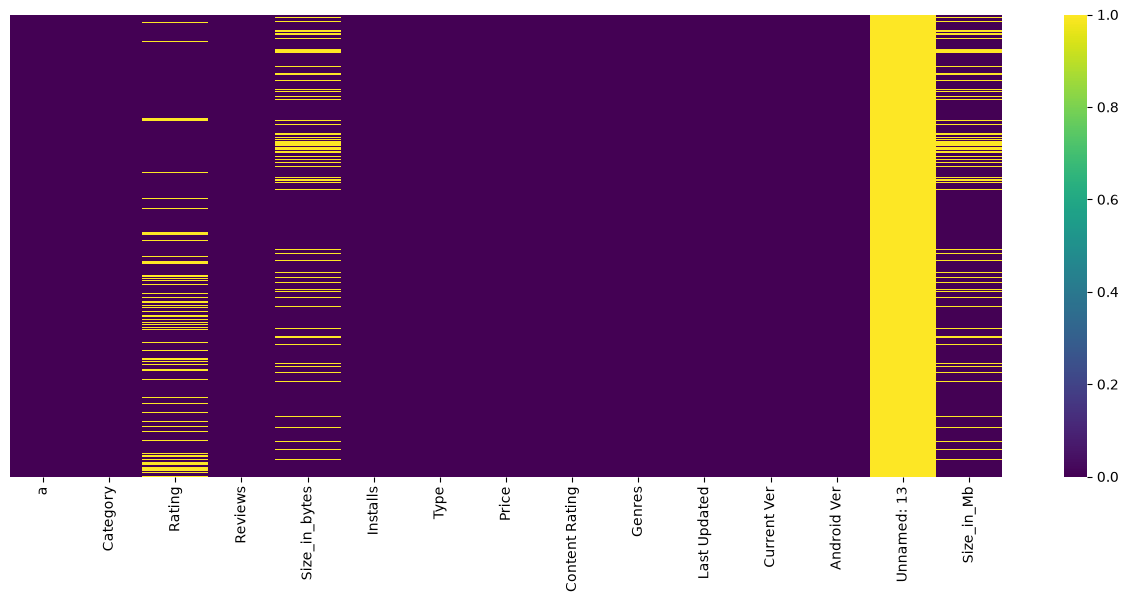

In [36]:
# make a figure size
plt.figure(figsize=(16, 6))
# plot the missing values in the columns
sns.heatmap(df.isnull(), cmap='viridis', cbar=True, yticklabels=False)

`After looking at the plot, it is clear that we need to drop Unnamed column as it has the maximum number of missing values`

In [39]:
# drop the column Unnamed: 13
df.drop(columns=['Unnamed: 13'], inplace=True)

In [40]:
df.head()

,a,Category,Rating,Reviews,Size_in_bytes,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_in_Mb
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19922944.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14680064.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,9122611.2,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,26214400.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2936012.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


**Achievement**

`We removed Unnamed Column from dataset`

Text(0, 0.5, 'Percentage of Missing Values')

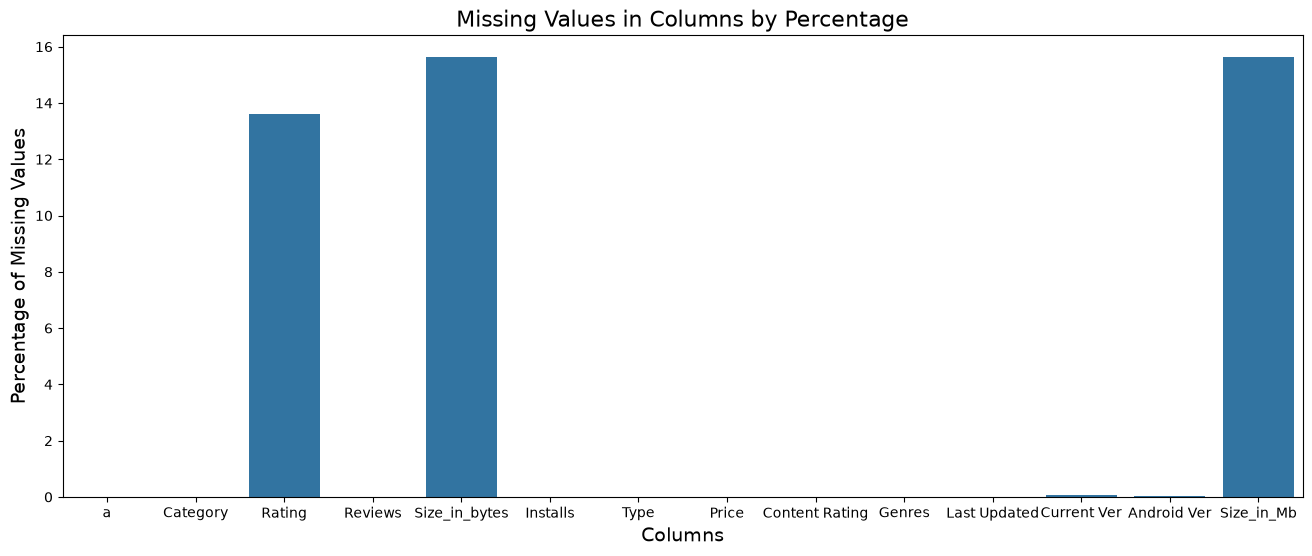

In [42]:
# let's plot missing values in all columns by their percentage

# 1. Plot the figure size
plt.figure(figsize=(16, 6))
# 2. plot missing values in all columns by their percentage
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum()/df.shape[0]*100)

# add labels
plt.title('Missing Values in Columns by Percentage', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Percentage of Missing Values', fontsize=14)

`Let's plot the missing values in other columns except Rating, Size in bytes, Size_in_mb`

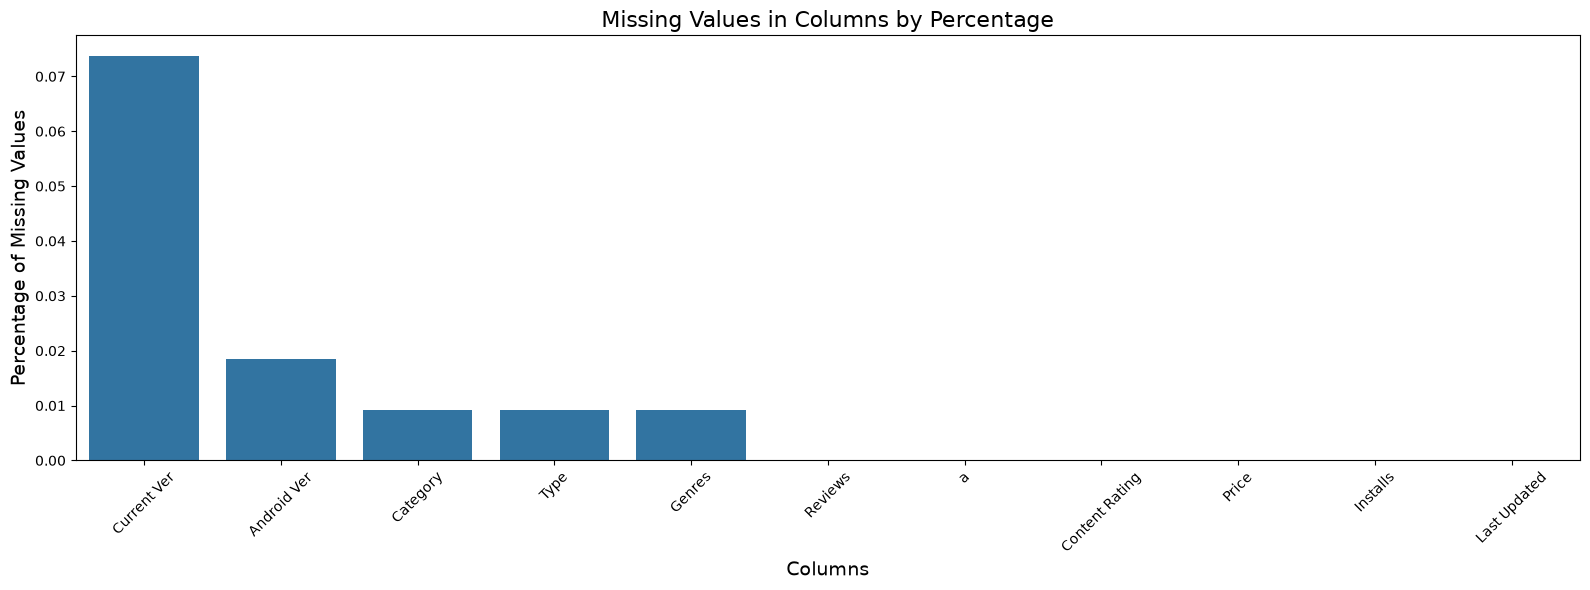

In [44]:
# plot missing values in all columns except Rating, Size_in_bytes and Size_in_Mb
exclude_cols = ['Rating', 'Size_in_bytes', 'Size_in_Mb']

missing_percentage = (
    df.drop(columns=exclude_cols, errors='ignore')
      .isnull()
      .sum()
      .div(df.shape[0])
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(16, 6))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values)
plt.title('Missing Values in Columns by Percentage', fontsize=16)
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Percentage of Missing Values', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

In [45]:
# let's check the missing values in all columns and sort them in decending order
df.isnull().sum().sort_values(ascending=False)

Size_in_bytes     1695
Size_in_Mb        1695
Rating            1474
Current Ver          8
Android Ver          2
Category             1
Genres               1
Type                 1
a                    0
Reviews              0
Installs             0
Price                0
Content Rating       0
Last Updated         0
dtype: int64